# EDA: speeches and energy mix (RQ1)

**RQ1:** *Among the world's major fossil-fuel economies, how does the frequency of energy-transition mentions in
their UN General Debate speeches correlate with the fossil-fuel share of their primary energy consumption after the
2015 Paris Agreement?*

We combine the mention counts (02), the fossil share of primary energy (03) and the group from 04, and look at the
relationship in three ways:

1. **Pooled:** every country-year is one point.
2. **Between countries:** one point per country. Do countries that talk more have a lower fossil share, or one that
   falls faster?
3. **Within countries:** does a country talk more in years when its fossil share is lower than usual?

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress, spearmanr

FIG_DIR = '../figures'
os.makedirs(FIG_DIR, exist_ok=True)

# One fixed colour per group, used in every chart below
MAJOR_COLOR = '#2a78d6'
OTHER_COLOR = '#eb6834'
INK = '#52514e'

plt.rcParams.update({
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': '#c3c2b7',
    'axes.grid': True,
    'grid.color': '#e1e0d9',
    'grid.linewidth': 0.6,
    'axes.axisbelow': True,
    'axes.titlesize': 11,
    'axes.labelcolor': INK,
    'xtick.color': INK,
    'ytick.color': INK,
    'legend.frameon': False,
})

## Speech features

Mentions per 1,000 words, because long speeches contain more mentions of any topic. `mentions_any` shows whether a
speech mentions the transition at all; most do not.

In [2]:
speeches = pd.read_parquet('../datasets/speeches_advanced_clean.parquet')
word_counts = pd.read_parquet('../datasets/speeches_simple_clean.parquet', columns=['WordCount'])

speeches = speeches.join(word_counts, how='left')
speeches = speeches.reset_index().rename(columns={'ISO-alpha3 Code': 'iso3'})
speeches['mentions_per_1k'] = speeches['transition_mention_count'] / speeches['WordCount'] * 1000
speeches['mentions_any'] = speeches['transition_mention_count'] > 0

speeches = speeches[['iso3', 'Year', 'Country or Area', 'WordCount',
                     'transition_mention_count', 'mentions_per_1k', 'mentions_any']]
print(speeches.shape)
speeches[['transition_mention_count', 'mentions_per_1k', 'mentions_any']].describe()

(2128, 7)


,transition_mention_count,mentions_per_1k
count,2128.000000,2128.000000
mean,0.671992,0.334148
std,1.367060,0.680655
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,1.000000,0.482975
max,20.000000,7.815553


## Add the group flag and fossil share

`major_fossil_economy` comes from 04, and `fossil_share_pct` (the share of primary energy from coal, oil and gas) from
03. OWID covers only 79 countries, so "other countries" means the other countries with fossil-share data. We keep the
country-years that have both a speech and a fossil share.

In [3]:
flags = pd.read_csv('../datasets/prepared_data/major_fossil_economies.csv')
major_iso3 = set(flags.loc[flags['major_fossil_economy'], 'iso3'])
print(f"{len(major_iso3)} major fossil-fuel economies: {', '.join(sorted(major_iso3))}")

panel = pd.read_csv('../datasets/prepared_data/master_panel_country_year.csv')
fossil_share = panel.loc[panel['Year'] >= 2015, ['iso3', 'Year', 'fossil_share_pct']].dropna()

speeches['major_fossil_economy'] = speeches['iso3'].isin(major_iso3)
combined = speeches.merge(fossil_share, on=['iso3', 'Year'], how='inner')

print(f"{len(combined)} country-years from {combined['iso3'].nunique()} countries")
print(combined.groupby('major_fossil_economy')['iso3'].nunique())

years_per_country = combined[combined['major_fossil_economy']].groupby('iso3')['Year'].agg(['count', 'min', 'max'])
years_per_country[years_per_country['count'] < 11]

15 major fossil-fuel economies: ARE, AUS, BRA, DZA, IDN, IRN, IRQ, KAZ, KWT, MEX, NOR, QAT, RUS, SAU, ZAF
792 country-years from 73 countries
major_fossil_economy
False    58
True     15
Name: iso3, dtype: int64


,count,min,max
iso3,,,
IRQ,3,2017,2019


All 15 countries have a speech and fossil-share data for every year 2015–2025, except Iraq (2017–2019 only). Iraq
gets no trend later, because three years are too few.

## How much do they talk about the transition?

All 2,128 speeches since 2015, the major fossil-fuel economies against all other countries: the share of speeches
that mention the transition, and mentions per 1,000 words.

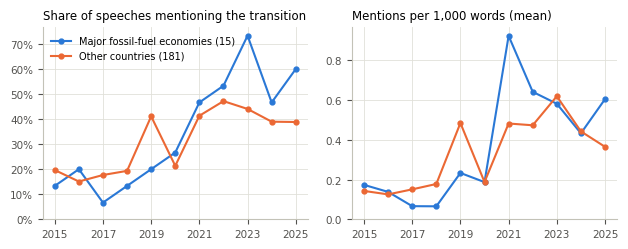

major_fossil_economy,False,True
Year,,
2015,0.20,0.13
2016,0.15,0.20
2017,0.18,0.07
2018,0.19,0.13
2019,0.41,0.20
2020,0.21,0.27
2021,0.41,0.47
2022,0.47,0.53
2023,0.44,0.73


In [4]:
yearly = (speeches.groupby(['Year', 'major_fossil_economy'])
          .agg(share_mentioning=('mentions_any', 'mean'), mentions_per_1k=('mentions_per_1k', 'mean'))
          .reset_index())

n_major = speeches.loc[speeches['major_fossil_economy'], 'iso3'].nunique()
n_other = speeches.loc[~speeches['major_fossil_economy'], 'iso3'].nunique()
groups = [(True, MAJOR_COLOR, f'Major fossil-fuel economies ({n_major})'), (False, OTHER_COLOR, f'Other countries ({n_other})')]

fig, axes = plt.subplots(1, 2, figsize=(6.4, 2.6))
views = [('share_mentioning', 'Share of speeches mentioning the transition', 100),
         ('mentions_per_1k', 'Mentions per 1,000 words (mean)', 1)]
for ax, (col, title, scale) in zip(axes, views):
    for is_major, color, label in groups:
        g = yearly[yearly['major_fossil_economy'] == is_major]
        ax.plot(g['Year'], g[col] * scale, color=color, linewidth=1.5, marker='o', markersize=3.5, label=label)
    ax.set_title(title, loc='left', fontsize=8.5)
    ax.tick_params(labelsize=7.5)
    ax.set_ylim(bottom=0)
    ax.set_xticks(range(2015, 2026, 2))
axes[0].yaxis.set_major_formatter(lambda v, _: f'{v:.0f}%')
axes[0].legend(loc='upper left', fontsize=7)
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/rq1_talk_over_time.png', dpi=200, bbox_inches='tight')
plt.show()

yearly.pivot(index='Year', columns='major_fossil_economy', values='share_mentioning').round(2)

Until 2018, at most about one in five speeches mentioned the transition. Other countries jumped in 2019 (UN Climate
Action Summit), the major fossil-fuel economies in 2021 (COP26), and since then they mention it more often: 73% in
2023, when the UAE hosted COP28. With only 15 countries this line is noisy, but they are clearly not quieter than the
rest.

## Country profiles

For each country: its talk, its fossil share at the start and the end, and the trend in its fossil share. The trend is
the slope of a straight line through the yearly values, in percentage points per year (negative means falling). A
slope uses all years, so one odd year like 2020 does not dominate. Only countries with at least 5 years get a trend.

In [5]:
def fossil_trend(group):
    if len(group) < 5:
        return np.nan
    return linregress(group['Year'], group['fossil_share_pct']).slope


trend = fossil_share.groupby('iso3')[['Year', 'fossil_share_pct']].apply(fossil_trend).rename('fossil_trend_pp_per_year')

talk = (speeches.groupby('iso3')
        .agg(country=('Country or Area', 'first'),
             major_fossil_economy=('major_fossil_economy', 'first'),
             speeches=('Year', 'size'),
             total_mentions=('transition_mention_count', 'sum'),
             share_mentioning=('mentions_any', 'mean'),
             mentions_per_1k=('mentions_per_1k', 'mean')))

energy = (fossil_share.sort_values('Year')
          .groupby('iso3')
          .agg(first_year=('Year', 'first'),
               last_year=('Year', 'last'),
               fossil_share_first=('fossil_share_pct', 'first'),
               fossil_share_last=('fossil_share_pct', 'last'),
               fossil_share_mean=('fossil_share_pct', 'mean'))
          .join(trend))

country = talk.join(energy, how='inner')
country['fossil_share_change'] = country['fossil_share_last'] - country['fossil_share_first']
print(country['major_fossil_economy'].value_counts())

major_profile = country[country['major_fossil_economy']].sort_values('mentions_per_1k', ascending=False)
major_profile.drop(columns='major_fossil_economy').round(2)

major_fossil_economy
False    58
True     15
Name: count, dtype: int64


,country,speeches,total_mentions,share_mentioning,mentions_per_1k,first_year,last_year,fossil_share_first,fossil_share_last,fossil_share_mean,fossil_trend_pp_per_year,fossil_share_change
iso3,,,,,,,,,,,,
BRA,Brazil,11,25,0.73,1.10,2015,2025,72.34,62.32,66.78,-0.93,-10.03
AUS,Australia,11,27,0.64,1.03,2015,2025,97.06,92.11,94.92,-0.53,-4.94
NOR,Norway,11,14,0.64,0.73,2015,2025,54.04,46.91,51.30,-0.71,-7.13
KAZ,Kazakhstan,11,15,0.73,0.69,2015,2025,98.48,98.07,98.34,-0.04,-0.41
ARE,United Arab Emirates,11,9,0.64,0.44,2015,2025,99.98,90.47,96.61,-1.13,-9.50
ZAF,South Africa,11,8,0.45,0.38,2015,2025,96.79,95.27,96.03,-0.10,-1.52
IDN,Indonesia,11,4,0.18,0.29,2015,2025,93.63,88.32,88.95,-0.60,-5.31
SAU,Saudi Arabia,11,6,0.27,0.24,2015,2025,100.00,99.41,99.89,-0.04,-0.59
QAT,Qatar,11,5,0.27,0.23,2015,2025,99.94,99.37,99.82,-0.05,-0.56


Brazil, Australia, Norway and Kazakhstan talk the most (0.7–1.1 mentions per 1,000 words). Russia and Algeria never
mention the transition, and Iran, Mexico and Kuwait only once or twice. Brazil, the UAE, Norway, Indonesia and
Australia lowered their fossil share by about 5–10 points, while Saudi Arabia, Qatar, Kuwait, Iraq and Algeria stayed
above 99%.

## Fossil share over time

One panel per country, ordered from the most talk (top left) to the least (bottom right). If talk and energy mix go
together, the falling lines should be at the top.

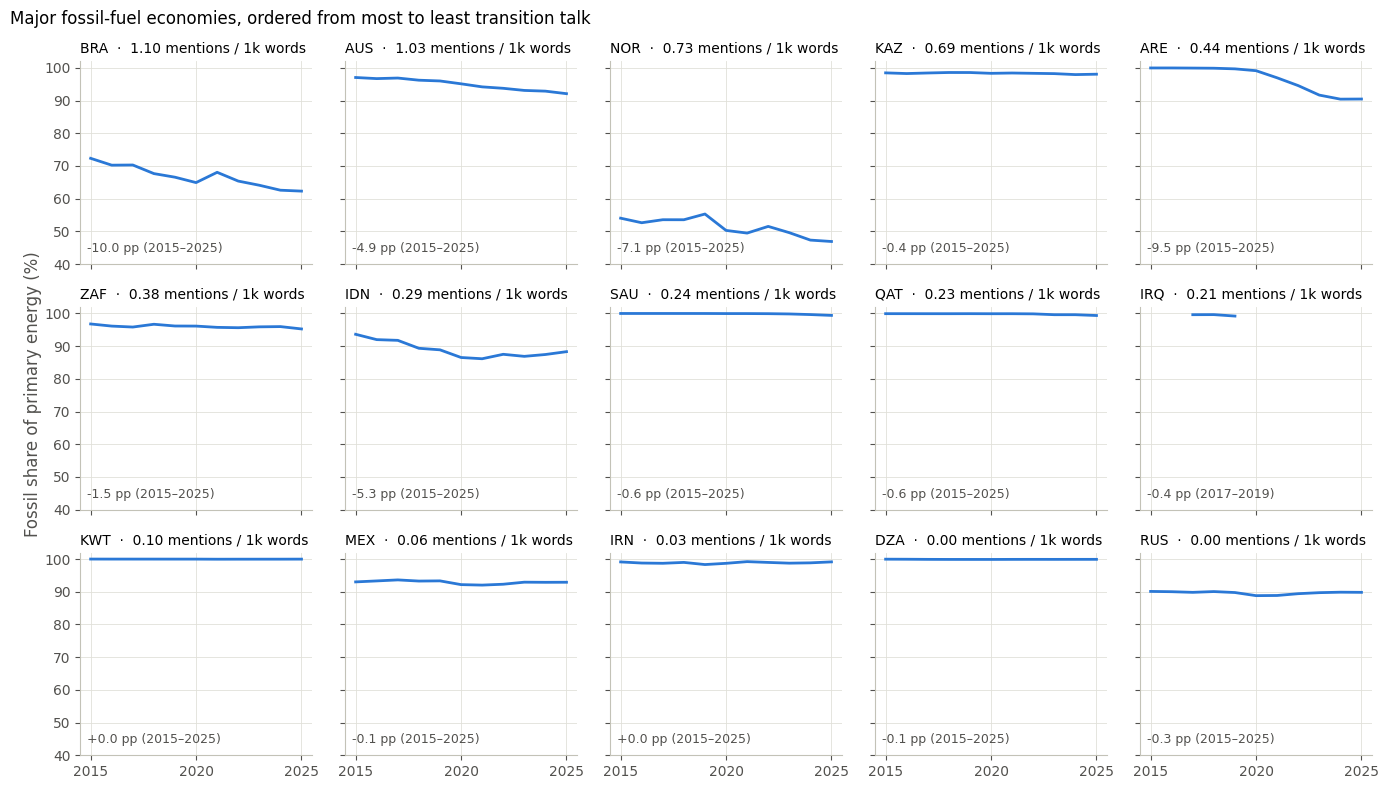

In [6]:
fig, axes = plt.subplots(3, 5, figsize=(14, 8), sharex=True, sharey=True)
for ax, (iso3, row) in zip(axes.flat, major_profile.iterrows()):
    series = fossil_share[fossil_share['iso3'] == iso3]
    ax.plot(series['Year'], series['fossil_share_pct'], color=MAJOR_COLOR, linewidth=2)
    ax.set_title(f"{iso3}  ·  {row['mentions_per_1k']:.2f} mentions / 1k words", loc='left', fontsize=10)
    change = round(row['fossil_share_change'], 1) + 0.0  # + 0.0 turns -0.0 into 0.0
    ax.text(0.03, 0.06, f"{change:+.1f} pp ({row['first_year']:.0f}–{row['last_year']:.0f})",
            transform=ax.transAxes, fontsize=9, color=INK)
axes[0, 0].set_ylim(40, 102)
axes[0, 0].set_xticks([2015, 2020, 2025])
fig.supylabel('Fossil share of primary energy (%)', color=INK)
fig.suptitle('Major fossil-fuel economies, ordered from most to least transition talk', x=0.01, ha='left', fontsize=12)
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/rq1_fossil_share_small_multiples.png', dpi=200, bbox_inches='tight')
plt.show()

Brazil, Australia, Norway and the UAE in the first row, and Indonesia, have falling lines. The last row (Kuwait,
Mexico, Iran, Algeria and Russia) is flat: little talk and little change. Kazakhstan is the exception: it talks about as
much as Norway but stays at about 98% fossil energy.

## Correlation between talk and fossil share

We use Spearman's ρ, because the mention rate has many zeros and is skewed, and there are only 14–15 countries. A
negative ρ means that more talk goes with a lower or faster-falling fossil share. Each correlation is computed for the
major fossil-fuel economies and for the other countries.

For the within-country version we subtract each country's mean, which removes fixed differences such as Norway's
hydropower, and each year's mean, which removes what happened everywhere, such as COVID or the general rise in climate
talk. The version with only the country means removed is shown as well.

In [7]:
results = []


def add_result(level, data, x_col, y_col):
    for is_major, group_name in [(True, 'Major fossil-fuel economies'), (False, 'Other countries')]:
        subset = data[data['major_fossil_economy'] == is_major].dropna(subset=[x_col, y_col])
        rho, p = spearmanr(subset[x_col], subset[y_col])
        results.append({'level': level, 'group': group_name, 'n': len(subset), 'spearman_rho': rho, 'p_value': p})


# Pooled: every country-year is one observation
add_result('Pooled: mentions vs fossil share (country-years)', combined, 'mentions_per_1k', 'fossil_share_pct')

# Between countries: one value per country
add_result('Between: mean mentions vs mean fossil share', country, 'mentions_per_1k', 'fossil_share_mean')
add_result('Between: mean mentions vs fossil share trend', country, 'mentions_per_1k', 'fossil_trend_pp_per_year')

# Within countries: remove each country's average, then each year's average (per group)
within = combined.copy()
for col in ['mentions_per_1k', 'fossil_share_pct']:
    within[col] = within[col] - within.groupby('iso3')[col].transform('mean')
add_result('Within: country averages removed', within, 'mentions_per_1k', 'fossil_share_pct')
for col in ['mentions_per_1k', 'fossil_share_pct']:
    within[col] = within[col] - within.groupby(['major_fossil_economy', 'Year'])[col].transform('mean')
add_result('Within: country and year averages removed', within, 'mentions_per_1k', 'fossil_share_pct')

results_table = pd.DataFrame(results)
results_table.round(3)

,level,group,n,spearman_rho,p_value
0,Pooled: mentions vs fossil share (country-years),Major fossil-fuel economies,157,-0.318,0.000
1,Pooled: mentions vs fossil share (country-years),Other countries,635,-0.072,0.071
2,Between: mean mentions vs mean fossil share,Major fossil-fuel economies,15,-0.479,0.071
3,Between: mean mentions vs mean fossil share,Other countries,58,-0.036,0.788
4,Between: mean mentions vs fossil share trend,Major fossil-fuel economies,14,-0.757,0.002
5,Between: mean mentions vs fossil share trend,Other countries,58,-0.007,0.960
6,Within: country averages removed,Major fossil-fuel economies,157,-0.250,0.002
7,Within: country averages removed,Other countries,635,-0.184,0.000
8,Within: country and year averages removed,Major fossil-fuel economies,157,-0.110,0.170
9,Within: country and year averages removed,Other countries,635,0.054,0.171


The between-country trend is the clearest result, so we plot it.

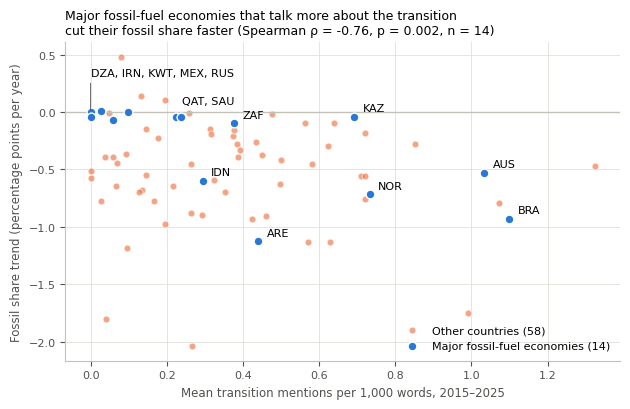

In [8]:
has_trend = country.dropna(subset=['fossil_trend_pp_per_year'])
majors = has_trend[has_trend['major_fossil_economy']]
others = has_trend[~has_trend['major_fossil_economy']]

fig, ax = plt.subplots(figsize=(6.4, 4.2))
ax.axhline(0, color='#c3c2b7', linewidth=1)
ax.scatter(others['mentions_per_1k'], others['fossil_trend_pp_per_year'], s=24, color=OTHER_COLOR, alpha=0.6,
           edgecolor='white', linewidth=0.8, label=f'Other countries ({len(others)})')
ax.scatter(majors['mentions_per_1k'], majors['fossil_trend_pp_per_year'], s=40, color=MAJOR_COLOR,
           edgecolor='white', linewidth=1, label=f'Major fossil-fuel economies ({len(majors)})', zorder=3)

# Dots that (almost) sit on top of each other share one label, e.g. the five producers that hardly
# ever mention the transition, all near (0, 0). That group sits among many orange dots, so its label goes
# into the empty space above, with a thin line down to the group; any other shared label goes just above
# its dots.
clusters = []
for iso3, row in majors.sort_values('mentions_per_1k').iterrows():
    x, y = row['mentions_per_1k'], row['fossil_trend_pp_per_year']
    if clusters and x - clusters[-1]['x'] < 0.13 and abs(y - clusters[-1]['y']) < 0.1:
        clusters[-1]['names'].append(iso3)
        clusters[-1]['y_min'] = min(clusters[-1]['y_min'], y)
    else:
        clusters.append({'x': x, 'y': y, 'y_min': y, 'names': [iso3]})
for c in clusters:
    if len(c['names']) == 1:
        ax.annotate(c['names'][0], (c['x'], c['y']), xytext=(6, 4), textcoords='offset points', fontsize=8)
    elif c['x'] < 0.1:
        ax.annotate(', '.join(sorted(c['names'])), (c['x'], c['y']), xytext=(c['x'], 0.3),
                    textcoords='data', fontsize=8, va='bottom',
                    arrowprops=dict(arrowstyle='-', color=INK, linewidth=0.6, relpos=(0, 0)))
    else:
        ax.annotate(', '.join(sorted(c['names'])), (c['x'], c['y']), xytext=(4, 10),
                    textcoords='offset points', fontsize=8)

rho, p = spearmanr(majors['mentions_per_1k'], majors['fossil_trend_pp_per_year'])
ax.set_title(f'Major fossil-fuel economies that talk more about the transition\n'
             f'cut their fossil share faster (Spearman ρ = {rho:.2f}, p = {p:.3f}, n = {len(majors)})',
             loc='left', fontsize=9)
ax.set_xlabel('Mean transition mentions per 1,000 words, 2015–2025', fontsize=8.5)
ax.set_ylabel('Fossil share trend (percentage points per year)', fontsize=8.5)
ax.tick_params(labelsize=8)
ax.legend(loc='lower right', fontsize=8)
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/rq1_talk_vs_fossil_trend.png', dpi=200, bbox_inches='tight')
plt.show()

**What the table shows:**

- **Pooled:** ρ = −0.32 for the major fossil-fuel economies, but this mixes differences between and within countries.
- **Between, level:** ρ = −0.48, p = 0.07; not significant with 15 countries.
- **Between, trend:** ρ = −0.76, p = 0.002, the strongest result. The countries that talk more cut their fossil share
  faster.
- **Other countries:** no relationship (ρ ≈ 0).
- **Within:** −0.25 and −0.18 with the country means removed, but −0.11 and +0.05 (not significant) once the year
  means are removed too. So that link was only the shared time trend.

## Robustness

With 14 countries a single country could drive the result, so we check:

1. **Leave one out:** ρ without each country in turn.
2. **Without the fossil ceiling:** drop the countries at 99%+ fossil energy, whose share can hardly move.

In [9]:
key = majors[['mentions_per_1k', 'fossil_trend_pp_per_year', 'fossil_share_mean']]

loo_rhos = pd.Series({iso3: spearmanr(key.drop(iso3)['mentions_per_1k'],
                                      key.drop(iso3)['fossil_trend_pp_per_year']).statistic
                      for iso3 in key.index})
print(f"All {len(key)} major fossil-fuel economies: rho = {rho:.2f}, p = {p:.3f}")
print(f"Leave one out: rho between {loo_rhos.min():.2f} (without {loo_rhos.idxmin()}) "
      f"and {loo_rhos.max():.2f} (without {loo_rhos.idxmax()})")

below_ceiling = key[key['fossil_share_mean'] < 99]
rho_bc, p_bc = spearmanr(below_ceiling['mentions_per_1k'], below_ceiling['fossil_trend_pp_per_year'])
dropped = sorted(set(key.index) - set(below_ceiling.index))
print(f"Without the countries at >= 99% fossil share ({', '.join(dropped)}): "
      f"rho = {rho_bc:.2f}, p = {p_bc:.3f}, n = {len(below_ceiling)}")

All 14 major fossil-fuel economies: rho = -0.76, p = 0.002
Leave one out: rho between -0.84 (without KAZ) and -0.72 (without BRA)
Without the countries at >= 99% fossil share (DZA, KWT, QAT, SAU): rho = -0.67, p = 0.033, n = 10


Leaving out one country keeps ρ between −0.84 (without Kazakhstan) and −0.72 (without Brazil). Without Algeria,
Kuwait, Qatar and Saudi Arabia, ρ is still −0.67 (p = 0.03, n = 10).

## Answer to RQ1

**Among the major fossil-fuel economies, the countries that talk more about the transition cut their fossil share of
primary energy faster after 2015** (ρ = −0.76, p = 0.002, n = 14). This holds when any country is left out and without
the ceiling countries.

What it does not show:

- no year-to-year link: countries do not talk more in the years their fossil share falls (within countries ρ = −0.11,
  p = 0.17);
- no link for the 58 other countries (ρ ≈ 0).

Caveats: with 14 countries and a correlation only, the direction could also be the other way round (countries with
progress to report talk more). The fossil share is about a country's own energy use, not its production, which is why
RQ2 looks at production. The keyword list does not count broader climate talk.

## Save

The country table and the correlation table, for the report.

In [10]:
country.to_csv('../datasets/prepared_data/rq1_country_summary.csv')
results_table.to_csv('../datasets/prepared_data/rq1_correlations.csv', index=False)
print(country.shape, results_table.shape)

(73, 13) (10, 5)
